# Анализ результатов Entity Resolution

Визуализация метрик после обучения `03_train_er_without_sm.py --all`.

Два уровня оценки:
- **In-domain**: test-сплит обучающих датасетов (модель видела домен при обучении)
- **Cross-domain**: все пары hold-out датасетов (модель НЕ видела ни одной строки)

Загружаем из `output/er_results_multidataset.json`.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120
matplotlib.rcParams["figure.figsize"] = (12, 5)

OUTPUT_DIR = Path("../output")
RESULTS_PATH = OUTPUT_DIR / "er_results_multidataset.json"

if RESULTS_PATH.exists():
    with open(RESULTS_PATH, encoding="utf-8") as f:
        results = json.load(f)
    print(f"Режим: {results['mode']}")
    print(f"Train датасетов: {len(results['train_datasets'])}")
    print(f"Holdout датасетов: {len(results['holdout_datasets'])}")
    print(f"Train triplets: {results['total_train_triplets']:,}")
    print(f"Val triplets: {results['total_val_triplets']:,}")
    if results.get("failed"):
        print(f"Failed: {results['failed']}")
else:
    raise FileNotFoundError(
        f"{RESULTS_PATH} не найден — сначала запустите:\n"
        "  python -m experiments.03_train_er_without_sm --all"
    )

Режим: multidataset_holdout
Train датасетов: 19
Holdout датасетов: 5
Train triplets: 6,220
Val triplets: 1,215


## 1. Кривые обучения (Train / Val Loss)

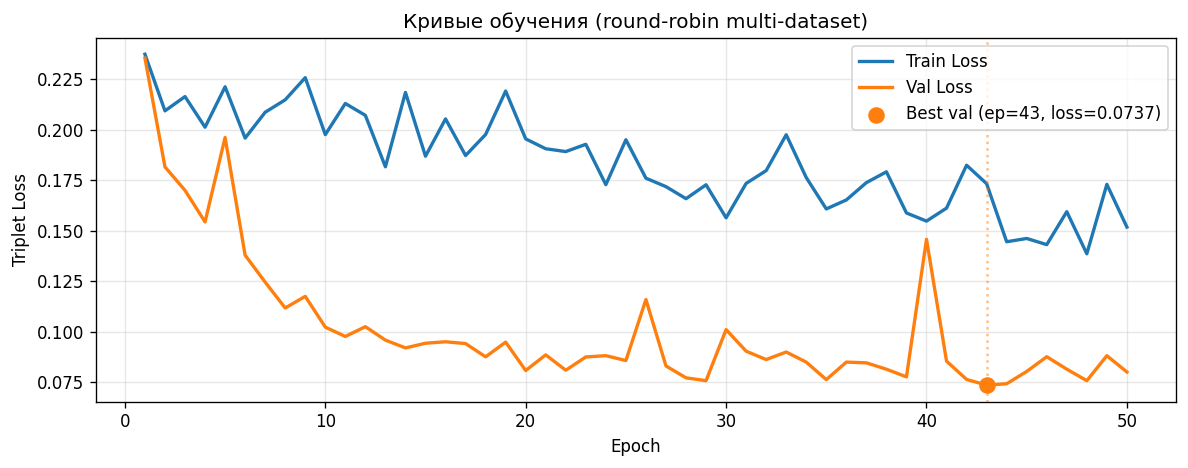

Final train loss: 0.1518
Best val loss: 0.0737 (epoch 43)


In [2]:
history = results["history"]

fig, ax = plt.subplots(figsize=(10, 4))
epochs = range(1, len(history["train_loss"]) + 1)
ax.plot(epochs, history["train_loss"], label="Train Loss", linewidth=2)
if history.get("val_loss"):
    ax.plot(epochs, history["val_loss"], label="Val Loss", linewidth=2)
    best_ep = int(np.argmin(history["val_loss"])) + 1
    best_val = min(history["val_loss"])
    ax.axvline(best_ep, color="C1", ls=":", alpha=0.5)
    ax.scatter([best_ep], [best_val], color="C1", s=80, zorder=5,
               label=f"Best val (ep={best_ep}, loss={best_val:.4f})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Triplet Loss")
ax.set_title("Кривые обучения (round-robin multi-dataset)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final train loss: {history['train_loss'][-1]:.4f}")
if history.get("val_loss"):
    print(f"Best val loss: {best_val:.4f} (epoch {best_ep})")

## 2. In-domain результаты (обучающие датасеты)

In [3]:
df_in = pd.DataFrame(results["in_domain_results"])
metric_cols = ["f1", "precision", "recall", "roc_auc", "avg_precision"]
show_cols = ["name", "domain"] + metric_cols + ["threshold", "n_pos", "n_neg", "duplicates_found"]
show_cols = [c for c in show_cols if c in df_in.columns]

display(df_in[show_cols].style
    .set_caption(f"In-domain: метрики на test-сплите ({len(df_in)} обучающих датасетов)")
    .background_gradient(subset=[c for c in metric_cols if c in df_in.columns], cmap="RdYlGn", vmin=0, vmax=1)
    .format({c: "{:.4f}" for c in metric_cols if c in df_in.columns})
)

for m in metric_cols:
    if m in df_in.columns:
        vals = df_in[m].dropna()
        print(f"  {m:15s}: {vals.mean():.4f} \u00b1 {vals.std():.4f}")

,name,domain,f1,precision,recall,roc_auc,avg_precision,threshold,n_pos,n_neg,duplicates_found
0,baby_products,baby products,0.4308,0.2745,1.0000,0.4393,0.2521,0.197994,14.000000,40.000000,11436055
1,beer,beer,0.7273,0.8889,0.6154,0.9109,0.8009,0.722238,13.000000,76.000000,246461
2,bikes,bikes,0.5098,0.4483,0.5909,0.6442,0.4707,0.658442,22.000000,64.000000,2250170
3,books1,books,0.8200,0.7593,0.8913,0.7035,0.8060,0.768100,46.000000,25.000000,410613
4,books3,books,0.9128,0.8395,1.0000,0.6998,0.8733,0.510093,68.000000,17.000000,887891
5,books4,books,0.5000,0.4062,0.6500,0.6885,0.3790,0.755423,20.000000,61.000000,1372883
6,books5,books,0.4615,0.3529,0.6667,0.7131,0.4260,0.713299,9.000000,67.000000,249145
7,cosmetics,cosmetics,nan,nan,nan,nan,nan,nan,nan,nan,18458769
8,ebooks1,ebooks,0.7636,0.7500,0.7778,0.8976,0.8686,0.727572,27.000000,47.000000,2913599
9,ebooks2,ebooks,nan,nan,nan,nan,nan,nan,nan,nan,1329302


  f1             : 0.6928 ± 0.1906
  precision      : 0.6551 ± 0.2629
  recall         : 0.8202 ± 0.1615
  roc_auc        : 0.7593 ± 0.1591
  avg_precision  : 0.6707 ± 0.2551


## 3. Cross-domain результаты (hold-out датасеты)

In [4]:
if results["cross_domain_results"]:
    df_cross = pd.DataFrame(results["cross_domain_results"])
    show_cols_cross = [c for c in show_cols if c in df_cross.columns]

    display(df_cross[show_cols_cross].style
        .set_caption(f"Cross-domain: метрики на {len(df_cross)} hold-out датасетах (модель их НЕ видела)")
        .background_gradient(subset=[c for c in metric_cols if c in df_cross.columns], cmap="RdYlGn", vmin=0, vmax=1)
        .format({c: "{:.4f}" for c in metric_cols if c in df_cross.columns})
    )

    for m in metric_cols:
        if m in df_cross.columns:
            vals = df_cross[m].dropna()
            print(f"  {m:15s}: {vals.mean():.4f} \u00b1 {vals.std():.4f}")
else:
    print("Нет cross-domain результатов (запуск с --no-holdout?)")
    df_cross = pd.DataFrame()

,name,domain,f1,precision,recall,roc_auc,avg_precision,threshold,n_pos,n_neg,duplicates_found
0,anime,anime,0.7595,0.7143,0.8108,0.8196,0.8384,0.502864,37,40,1057315
1,books2,books,0.4167,0.2727,0.8824,0.5304,0.2683,0.339693,17,58,315021
2,citations,bibliography,0.3944,0.2500,0.9333,0.4981,0.2900,0.403456,15,53,1733997
3,electronics,electronics,0.5556,0.4545,0.7143,0.7951,0.5046,0.779486,14,61,6443154
4,restaurants3,restaurants,0.5806,0.6000,0.5625,0.7645,0.5247,0.647147,16,56,7374210


  f1             : 0.5413 ± 0.1470
  precision      : 0.4583 ± 0.2021
  recall         : 0.7807 ± 0.1471
  roc_auc        : 0.6815 ± 0.1544
  avg_precision  : 0.4852 ± 0.2301


## 4. Сравнение In-domain vs Cross-domain

C:\Users\olegk\AppData\Local\Temp\ipykernel_5804\1090788362.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([in_vals, cross_vals], labels=["In-domain", "Cross-domain"],
C:\Users\olegk\AppData\Local\Temp\ipykernel_5804\1090788362.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([in_vals, cross_vals], labels=["In-domain", "Cross-domain"],
C:\Users\olegk\AppData\Local\Temp\ipykernel_5804\1090788362.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([in_vals, cross_vals], labels=["In-domain", "Cross-domain"],


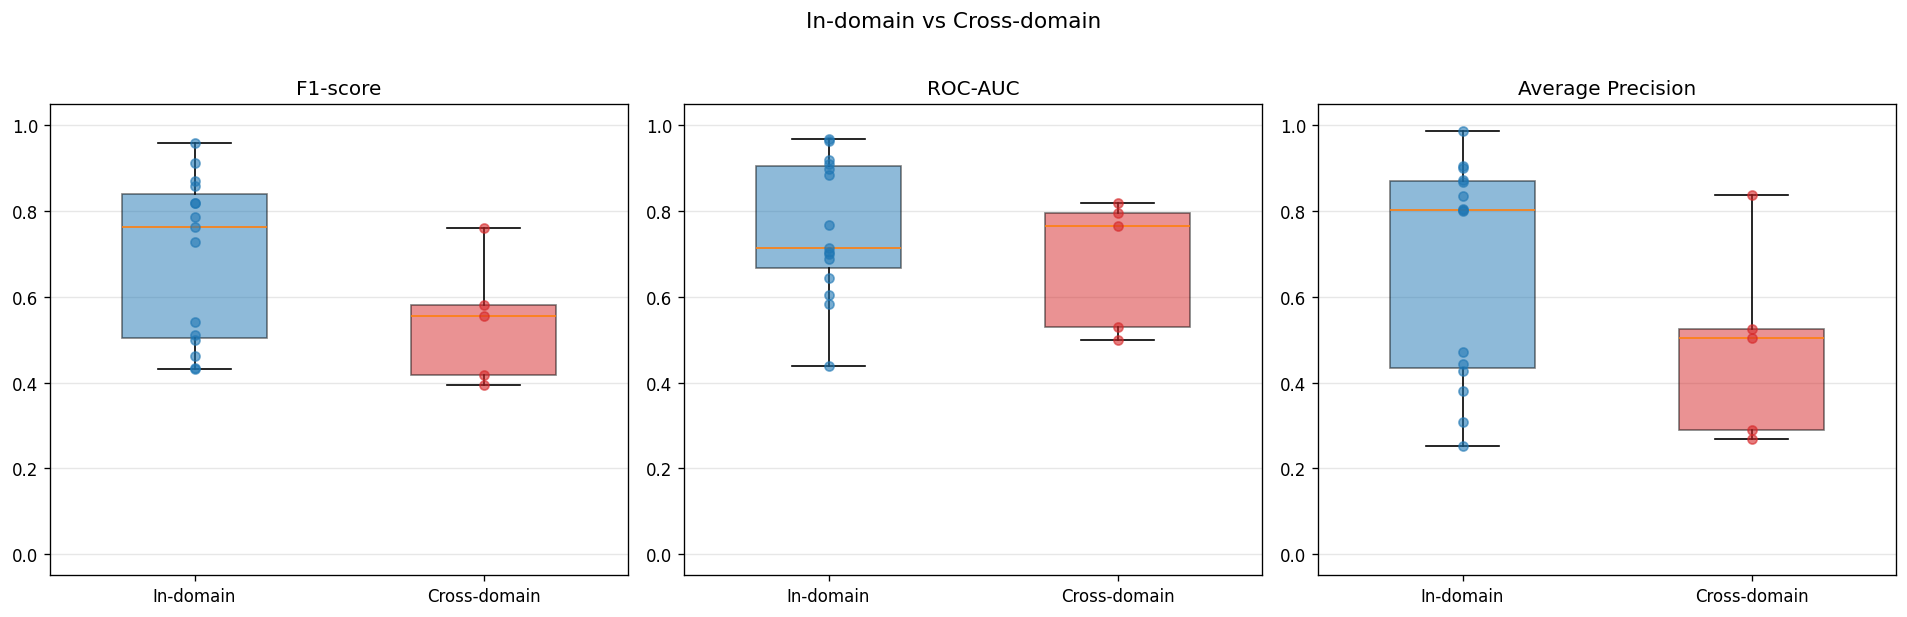

,Metric,In-domain (mean),Cross-domain (mean),Drop
0,F1,0.6928,0.5413,0.1515
1,ROC-AUC,0.7593,0.6815,0.0778
2,Avg Precision,0.6707,0.4852,0.1855


In [5]:
if not df_cross.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    for ax, metric, title in zip(axes, ["f1", "roc_auc", "avg_precision"],
                                       ["F1-score", "ROC-AUC", "Average Precision"]):
        in_vals = df_in[metric].dropna()
        cross_vals = df_cross[metric].dropna()

        bp = ax.boxplot([in_vals, cross_vals], labels=["In-domain", "Cross-domain"],
                        patch_artist=True, widths=0.5)
        bp["boxes"][0].set_facecolor("C0")
        bp["boxes"][0].set_alpha(0.5)
        bp["boxes"][1].set_facecolor("C3")
        bp["boxes"][1].set_alpha(0.5)

        ax.scatter(np.ones(len(in_vals)), in_vals, alpha=0.6, s=30, zorder=5, color="C0")
        ax.scatter(np.ones(len(cross_vals)) * 2, cross_vals, alpha=0.6, s=30, zorder=5, color="C3")

        ax.set_title(title)
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3, axis="y")

    plt.suptitle("In-domain vs Cross-domain", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    comparison = pd.DataFrame({
        "Metric": ["F1", "ROC-AUC", "Avg Precision"],
        "In-domain (mean)": [df_in["f1"].mean(), df_in["roc_auc"].mean(), df_in["avg_precision"].mean()],
        "Cross-domain (mean)": [df_cross["f1"].mean(), df_cross["roc_auc"].mean(), df_cross["avg_precision"].mean()],
    })
    comparison["Drop"] = comparison["In-domain (mean)"] - comparison["Cross-domain (mean)"]
    display(comparison.style.format("{:.4f}", subset=["In-domain (mean)", "Cross-domain (mean)", "Drop"])
            .set_caption("Падение метрик на unseen доменах"))
else:
    print("Нет cross-domain результатов для сравнения.")

## 5. F1 по каждому датасету (bar chart)

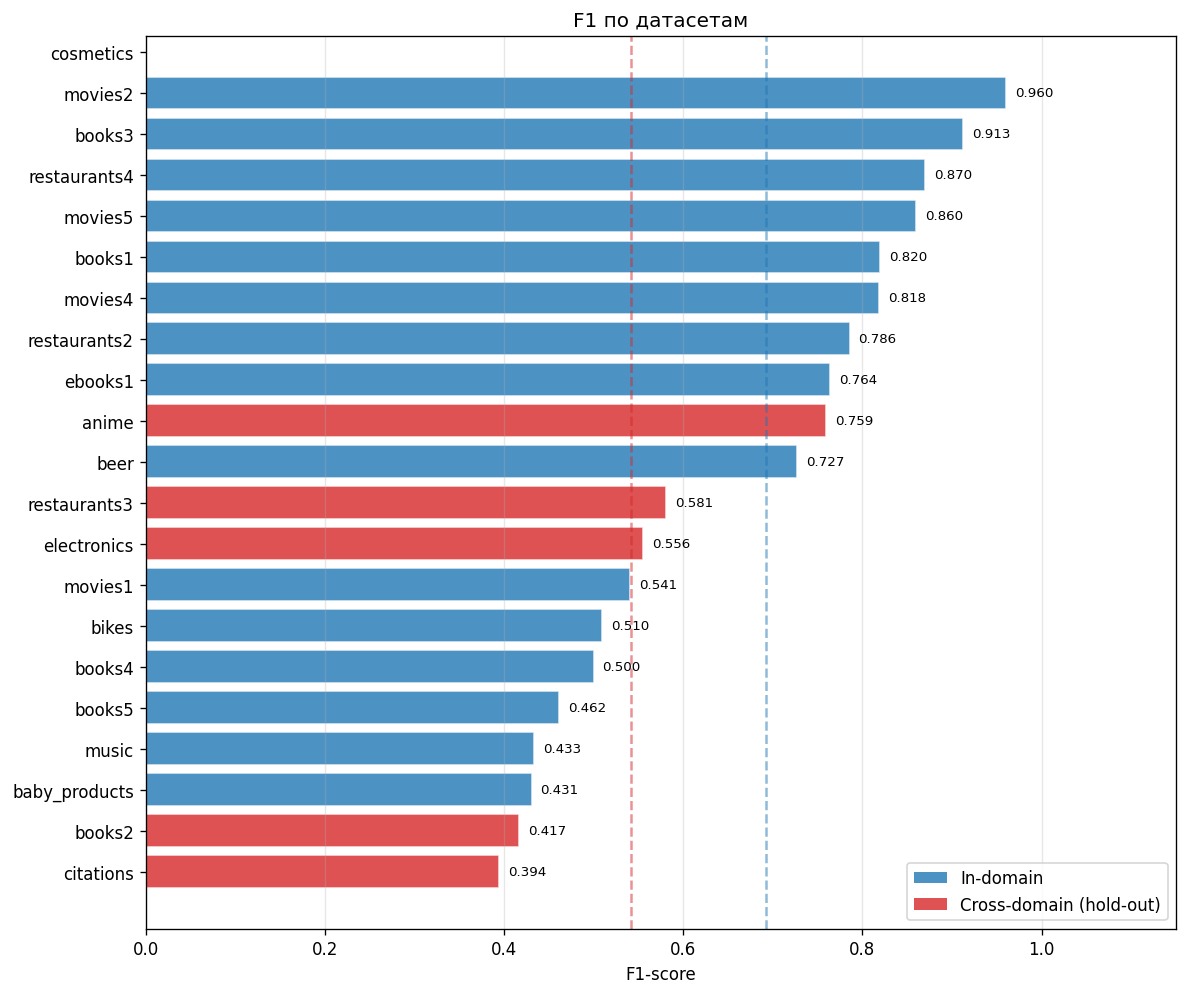

In [6]:
df_all = pd.concat([df_in, df_cross], ignore_index=True) if not df_cross.empty else df_in.copy()
df_all = df_all.sort_values("f1", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(df_all) * 0.35)))

colors = ["C3" if et == "cross-domain" else "C0" for et in df_all["eval_type"]]
bars = ax.barh(df_all["name"], df_all["f1"], color=colors, alpha=0.8, edgecolor="white")

for bar, f1 in zip(bars, df_all["f1"]):
    if pd.notna(f1):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{f1:.3f}", va="center", fontsize=8)

ax.set_xlabel("F1-score")
ax.set_xlim(0, 1.15)
ax.set_title("F1 по датасетам")
ax.axvline(df_in["f1"].mean(), color="C0", ls="--", alpha=0.5,
           label=f"In-domain mean={df_in['f1'].mean():.3f}")
if not df_cross.empty:
    ax.axvline(df_cross["f1"].mean(), color="C3", ls="--", alpha=0.5,
               label=f"Cross-domain mean={df_cross['f1'].mean():.3f}")

handles = [Patch(facecolor="C0", alpha=0.8, label="In-domain"),
           Patch(facecolor="C3", alpha=0.8, label="Cross-domain (hold-out)")]
ax.legend(handles=handles, loc="lower right")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

## 6. Метрики по доменам

In [7]:
domain_agg = (df_all.groupby(["domain", "eval_type"])
              .agg(f1=("f1", "mean"), roc_auc=("roc_auc", "mean"),
                   avg_precision=("avg_precision", "mean"), n_datasets=("name", "count"))
              .sort_values("f1", ascending=False))

display(domain_agg.style
    .set_caption("Средние метрики по доменам")
    .format({"f1": "{:.4f}", "roc_auc": "{:.4f}", "avg_precision": "{:.4f}"})
    .background_gradient(subset=["f1"], cmap="RdYlGn", vmin=0, vmax=1)
)

,,f1,roc_auc,avg_precision,n_datasets
domain,eval_type,,,,
restaurants,in-domain,0.8276,0.9422,0.8700,3
movies,in-domain,0.7946,0.8064,0.7836,5
ebooks,in-domain,0.7636,0.8976,0.8686,2
anime,cross-domain,0.7595,0.8196,0.8384,1
beer,in-domain,0.7273,0.9109,0.8009,1
books,in-domain,0.6736,0.7012,0.6211,4
restaurants,cross-domain,0.5806,0.7645,0.5247,1
electronics,cross-domain,0.5556,0.7951,0.5046,1
bikes,in-domain,0.5098,0.6442,0.4707,1


## 7. Precision-Recall scatter

C:\Users\olegk\AppData\Local\Temp\ipykernel_5804\346909403.py:16: RuntimeWarning: divide by zero encountered in divide
  p = (f1_target * r) / (2 * r - f1_target)


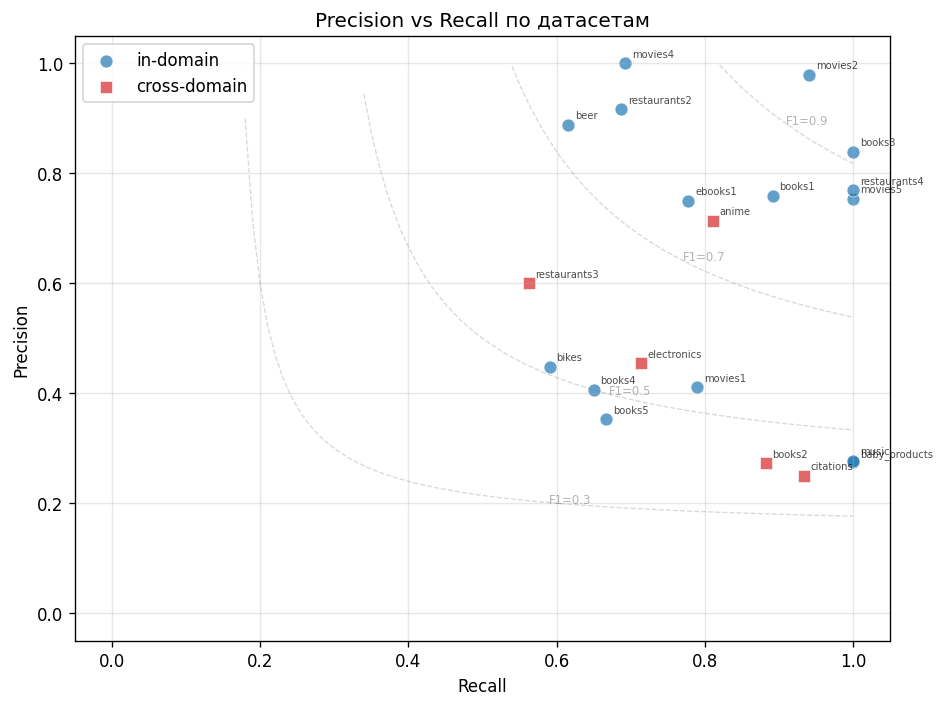

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

for eval_type, color, marker in [("in-domain", "C0", "o"), ("cross-domain", "C3", "s")]:
    subset = df_all[df_all["eval_type"] == eval_type]
    if subset.empty or "recall" not in subset.columns:
        continue
    ax.scatter(subset["recall"], subset["precision"], c=color, marker=marker,
               s=60, alpha=0.7, label=eval_type, edgecolors="white", linewidths=0.5)
    for _, row in subset.iterrows():
        ax.annotate(row["name"], (row["recall"], row["precision"]),
                    fontsize=6, alpha=0.7, xytext=(4, 4), textcoords="offset points")

# Изолинии F1
for f1_target in [0.3, 0.5, 0.7, 0.9]:
    r = np.linspace(0.01, 1, 100)
    p = (f1_target * r) / (2 * r - f1_target)
    mask = (p > 0) & (p <= 1)
    ax.plot(r[mask], p[mask], "--", color="gray", alpha=0.3, linewidth=0.8)
    valid_idx = np.where(mask)[0]
    if len(valid_idx) > 0:
        mid = valid_idx[len(valid_idx) // 2]
        ax.text(r[mid], p[mid], f"F1={f1_target}", fontsize=7, color="gray", alpha=0.6)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision vs Recall по датасетам")
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Распределение оптимальных порогов

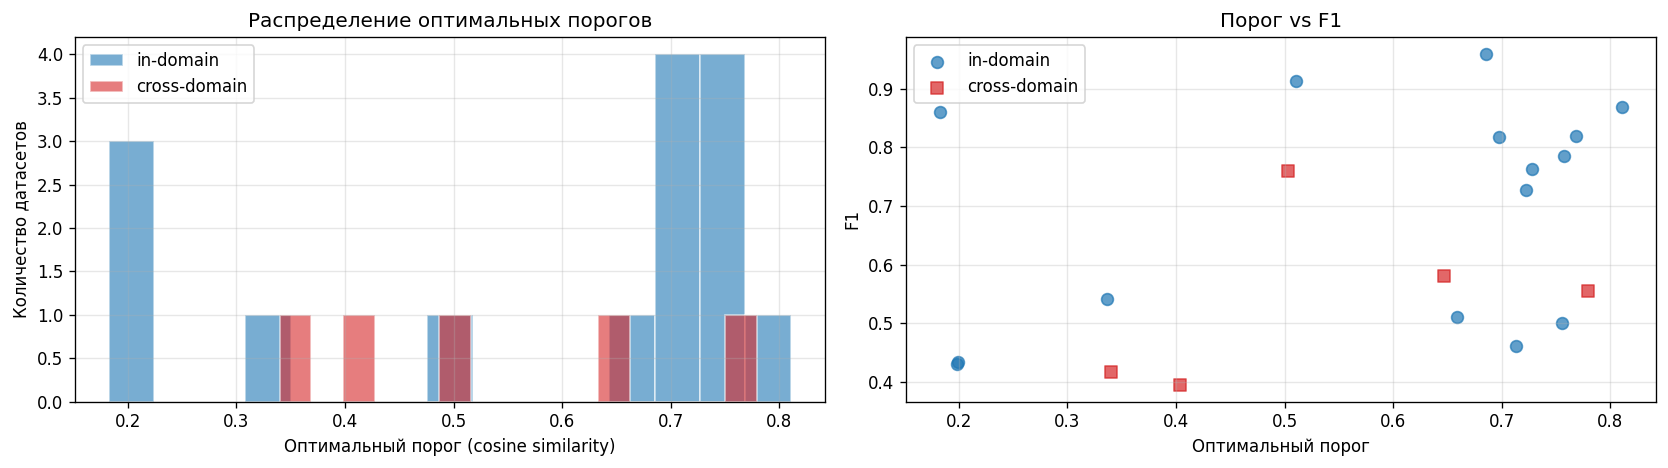

Медианный порог (in-domain): 0.698
Медианный порог (cross-domain): 0.503


In [9]:
if "threshold" in df_all.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for eval_type, color in [("in-domain", "C0"), ("cross-domain", "C3")]:
        subset = df_all[df_all["eval_type"] == eval_type]
        if not subset.empty:
            axes[0].hist(subset["threshold"].dropna(), bins=15, alpha=0.6,
                         color=color, label=eval_type, edgecolor="white")
    axes[0].set_xlabel("Оптимальный порог (cosine similarity)")
    axes[0].set_ylabel("Количество датасетов")
    axes[0].set_title("Распределение оптимальных порогов")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    for eval_type, color, marker in [("in-domain", "C0", "o"), ("cross-domain", "C3", "s")]:
        subset = df_all[df_all["eval_type"] == eval_type]
        if not subset.empty:
            axes[1].scatter(subset["threshold"], subset["f1"], c=color,
                           marker=marker, s=50, alpha=0.7, label=eval_type)
    axes[1].set_xlabel("Оптимальный порог")
    axes[1].set_ylabel("F1")
    axes[1].set_title("Порог vs F1")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Медианный порог (in-domain): {df_in['threshold'].median():.3f}")
    if not df_cross.empty:
        print(f"Медианный порог (cross-domain): {df_cross['threshold'].median():.3f}")

## 9. Итоговая сводка

In [10]:
print("=" * 60)
print("ИТОГОВАЯ СВОДКА")
print("=" * 60)
print(f"Модель: output/er_model_multidataset.pt")
print(f"Эпох: {len(history['train_loss'])}")
print(f"Train датасетов: {len(results['train_datasets'])}  {results['train_datasets']}")
print(f"Holdout датасетов: {len(results['holdout_datasets'])}  {results['holdout_datasets']}")
print()

def _print_summary(label, df):
    print(f"--- {label} ---")
    for metric in ["f1", "roc_auc", "avg_precision"]:
        if metric in df.columns:
            vals = df[metric].dropna()
            print(f"  {metric:15s}: {vals.mean():.4f} \u00b1 {vals.std():.4f}  "
                  f"(min={vals.min():.4f}, max={vals.max():.4f})")

_print_summary("IN-DOMAIN (test split)", df_in)
if not df_cross.empty:
    print()
    _print_summary("CROSS-DOMAIN (hold-out, все пары)", df_cross)

print()
print("Худшие датасеты (F1 < 0.5):")
worst = df_all[df_all["f1"] < 0.5][["name", "eval_type", "f1", "roc_auc"]]
if len(worst) > 0:
    for _, row in worst.iterrows():
        print(f"  {row['name']:20s} ({row['eval_type']}) "
              f"\u2014 F1={row['f1']:.4f}, AUC={row['roc_auc']:.4f}")
else:
    print("  Нет (все F1 >= 0.5)")

ИТОГОВАЯ СВОДКА
Модель: output/er_model_multidataset.pt
Эпох: 50
Train датасетов: 19  ['baby_products', 'beer', 'bikes', 'books1', 'books3', 'books4', 'books5', 'cosmetics', 'ebooks1', 'ebooks2', 'movies1', 'movies2', 'movies3', 'movies4', 'movies5', 'music', 'restaurants1', 'restaurants2', 'restaurants4']
Holdout датасетов: 5  ['anime', 'books2', 'citations', 'electronics', 'restaurants3']

--- IN-DOMAIN (test split) ---
  f1             : 0.6928 ± 0.1906  (min=0.4308, max=0.9600)
  roc_auc        : 0.7593 ± 0.1591  (min=0.4393, max=0.9694)
  avg_precision  : 0.6707 ± 0.2551  (min=0.2521, max=0.9874)

--- CROSS-DOMAIN (hold-out, все пары) ---
  f1             : 0.5413 ± 0.1470  (min=0.3944, max=0.7595)
  roc_auc        : 0.6815 ± 0.1544  (min=0.4981, max=0.8196)
  avg_precision  : 0.4852 ± 0.2301  (min=0.2683, max=0.8384)

Худшие датасеты (F1 < 0.5):
  citations            (cross-domain) — F1=0.3944, AUC=0.4981
  books2               (cross-domain) — F1=0.4167, AUC=0.5304
  baby_produ